In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

In [4]:
df = pd.read_csv("../Dataset/cleaned_accidents.csv")

In [5]:
df.head()

,Severity,Start_Time,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,City,State,Start_Lat,Start_Lng,Hour,Month,Day
0,3,2016-02-08 05:46:00,36.9,91.0,10.0,Light Rain,Dayton,OH,39.865147,-84.058723,5,2,8
1,2,2016-02-08 06:07:59,37.9,100.0,10.0,Light Rain,Reynoldsburg,OH,39.928059,-82.831184,6,2,8
2,2,2016-02-08 06:49:27,36.0,100.0,10.0,Overcast,Williamsburg,OH,39.063148,-84.032608,6,2,8
3,3,2016-02-08 07:23:34,35.1,96.0,9.0,Mostly Cloudy,Dayton,OH,39.747753,-84.205582,7,2,8
4,2,2016-02-08 07:39:07,36.0,89.0,6.0,Mostly Cloudy,Dayton,OH,39.627781,-84.188354,7,2,8


In [6]:
df_sample = df.sample(n=100000, random_state=42)

In [7]:
df_sample.shape

(100000, 13)

In [8]:
heat_data = df_sample[['Start_Lat', 'Start_Lng']].values.tolist()

In [9]:
map_center = [df_sample['Start_Lat'].mean(), df_sample['Start_Lng'].mean()]

In [10]:
accident_map = folium.Map(location=map_center, zoom_start=4)

In [11]:
HeatMap(heat_data).add_to(accident_map)

In [12]:
accident_map.save("../Images/hotspot_heatmap.html")

In [13]:
df_sample['Risk_Zone'] = np.where(
    df_sample['Severity'] >=3,
    'High Risk',
    'Low Risk'
)

In [14]:
df_sample['Risk_Zone'].value_counts()

Risk_Zone
Low Risk     79566
High Risk    20434
Name: count, dtype: int64

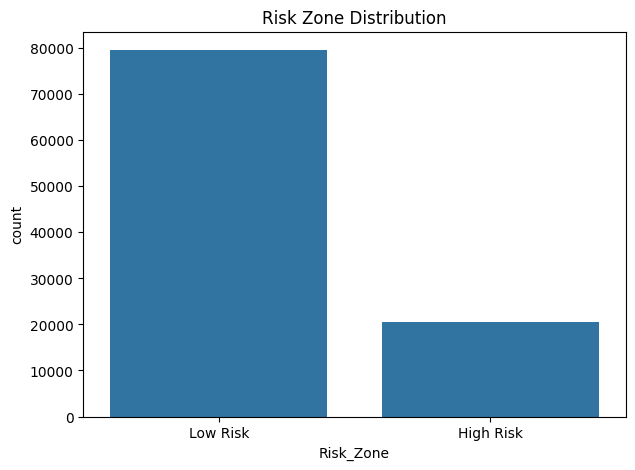

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Risk_Zone',
    data=df_sample
)

plt.title(
    "Risk Zone Distribution"
)

plt.savefig(
    "../Images/risk_zone_distribution.png"
)

plt.show()

In [16]:
top_cities = (
    df_sample['City']
    .value_counts()
    .head(15)
)

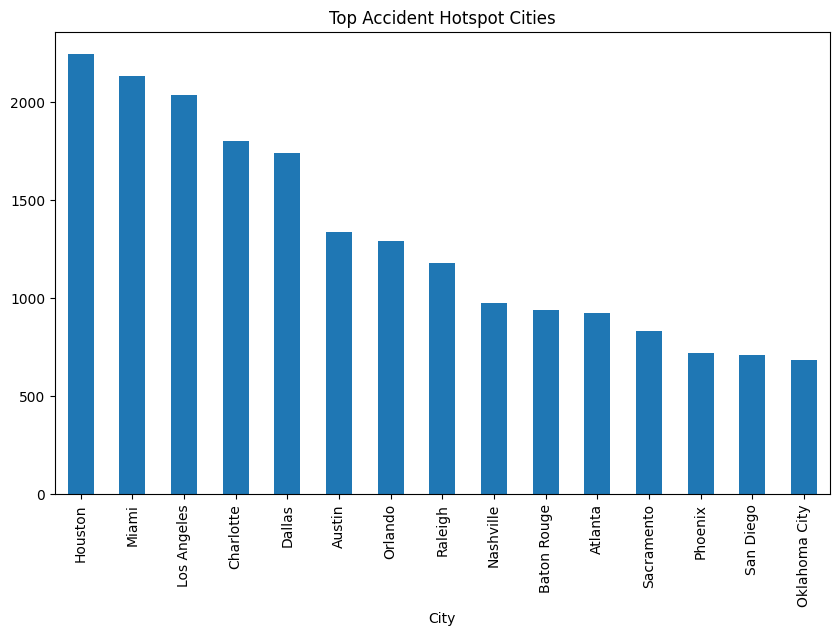

In [17]:
plt.figure(figsize=(10,6))

top_cities.plot(kind='bar')

plt.title(
    "Top Accident Hotspot Cities"
)

plt.xticks(rotation=90)

plt.savefig(
    "../Images/top_hotspot_cities.png"
)

plt.show()

In [18]:
severity_data = df_sample[
    df_sample['Severity'] >= 3  
]

In [19]:
high_risk_heat = severity_data[['Start_Lat', 'Start_Lng']].values.tolist()

In [20]:
high_risk_map = folium.Map(location=map_center, zoom_start=4)

In [21]:
HeatMap(high_risk_heat).add_to(high_risk_map)

In [22]:
high_risk_map.save("../Images/high_risk_hotspot_heatmap.html")